# <font color="brown">Credit Default Prediction with an sklearn Pipeline </font>

## <font color = "brown">Problem Statement </font>

### <font color="blue"> Context

The `Decision Trees` case study built a credit-default classifier on this same customer dataset by
manually one-hot encoding every categorical column with `pd.get_dummies`, training a Decision
Tree, and tuning it with `GridSearchCV`. That's the normal way to build and select a model. Once a
model is selected, though, "encode by hand, then train" is still two separate steps a real
deployment has to remember to repeat, in order, on every new batch of raw data. This case study
builds a model the normal way first, then shows what changes when that finished model is packaged
into a single `Pipeline` object.

### <font color="blue"> Objective

- Build and tune a Decision Tree the traditional way: engineer a feature, impute, encode
  manually, train, then use `GridSearchCV` to select the best hyperparameters.
- Only after a final model is selected, wrap the feature engineering, imputation, and encoding
  steps together with the tuned model into one `Pipeline` using `make_pipeline`.
- Confirm the packaged pipeline reproduces the selected model's result exactly.

### <font color="blue"> Data Dictionary

Same dataset as the `Decision Trees` case study (`default_on_payment.csv`, 5,000 customers,
copied into this folder): credit history, account status, loan amount, employment, and
demographic fields, with `Default_On_Payment` (1 = defaulted, 0 = repaid) as the target. Unlike the
original version, this copy has missing values in two numeric columns (`Credit_Amount`, `Age`) and
two categorical columns (`Savings_Acc`, `Job`), deliberately, so both the manual approach and the
pipeline have to actually handle missing data, not just encoding.

## <font color="brown"> Importing Necessary Libraries</font>

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import recall_score, confusion_matrix, ConfusionMatrixDisplay

%matplotlib inline

## <font color="brown"> Reading the Data</font>

In [2]:
df = pd.read_csv("default_on_payment.csv")
df = df.drop(columns=["Customer_ID"])
print(df.shape)
df.head()

(5000, 21)


,Status_Checking_Acc,Duration_in_Months,Credit_History,Purposre_Credit_Taken,Credit_Amount,Savings_Acc,Years_At_Present_Employment,Inst_Rt_Income,Marital_Status_Gender,Other_Debtors_Guarantors,...,Property,Age,Other_Inst_Plans,Housing,Num_CC,Job,Dependents,Telephone,Foreign_Worker,Default_On_Payment
0,A11,6,A34,A43,1169.0,A65,A75,4,A93,A101,...,A121,67.0,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951.0,A61,A73,2,A92,A101,...,A121,22.0,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096.0,A61,A74,2,A93,A101,...,A121,49.0,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882.0,A61,A74,2,A93,A103,...,A122,45.0,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870.0,A61,A73,3,A93,A101,...,A124,53.0,A143,A153,2,A173,2,A191,A201,1


In [3]:
missing = df.isnull().sum()
missing[missing > 0]

Credit_Amount    285
Savings_Acc      317
Age              256
Job              237
dtype: int64

## <font color="brown"> Understanding Data Leakage</font>

Before writing any modeling code: **data leakage** is when information that would not actually be
available at prediction time quietly influences training, making a model look better during
evaluation than it will ever perform in reality.

The most obvious form is leaking the target itself (using a column that is only known after the
outcome happened). A subtler, easy-to-miss form is leaking through *preprocessing*: any statistic
learned from data, a mean, a median, a mode, a category's frequency, is exactly as much a "learned
value" as a model's coefficients are. If that statistic is computed from the full dataset (train
and test combined) and only *then* is the data split, the test rows have already quietly shaped a
value that gets used on the training rows, and vice versa. The evaluation on that "test" set is no
longer a fair preview of unseen data, because the preprocessing already peeked at it.

> **The rule**: fit every learned statistic on the training split only. Apply it, unchanged, to test.

This is exactly why the very first thing done with this dataset, before any feature engineering,
before imputing a single missing value, before encoding a single category, is splitting it into
train and test. Everything that follows (the median used to fill `Credit_Amount`, the mode used to
fill `Job`, the categories `pd.get_dummies` learns) is fit on the training split alone.

## <font color="brown"> Step 1: Split the Data, Then Build a Base Model</font>

The traditional way: split, engineer a feature, fill in the missing values by hand, encode the
categorical columns with `pd.get_dummies`, then train a Decision Tree on the result. A plain
`DecisionTreeClassifier` can't accept missing values at all, so imputing isn't optional, unlike
encoding, skipping it would crash training outright.

In [4]:
X = df.drop(columns=["Default_On_Payment"])
y = df["Default_On_Payment"]

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numeric_cols = X.select_dtypes(exclude="object").columns.tolist()

C:\Users\yoges\AppData\Local\Temp\ipykernel_26408\125723357.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns.tolist()


**Split first**, on the raw, un-engineered, un-imputed data, before anything else touches it:

In [5]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print("Train:", X_train_raw.shape, " Test:", X_test_raw.shape)

Train: (3500, 20)  Test: (1500, 20)


**Then engineer, impute using train-only statistics, and encode**, applying each to both splits:

In [6]:
def engineer_feature(frame):
    frame = frame.copy()
    frame["Amount_per_Month"] = frame["Credit_Amount"] / frame["Duration_in_Months"]
    return frame

X_train_fe = engineer_feature(X_train_raw)
X_test_fe = engineer_feature(X_test_raw)
numeric_cols_engineered = numeric_cols + ["Amount_per_Month"]

median_fill = X_train_fe[numeric_cols_engineered].median()
mode_fill = X_train_fe[categorical_cols].mode().iloc[0]

def impute(frame):
    frame = frame.copy()
    for col in numeric_cols_engineered:
        frame[col] = frame[col].fillna(median_fill[col])
    for col in categorical_cols:
        frame[col] = frame[col].fillna(mode_fill[col])
    return frame

X_train_imputed = impute(X_train_fe)
X_test_imputed = impute(X_test_fe)

print("Missing values remaining -- train:", X_train_imputed.isnull().sum().sum(),
      " test:", X_test_imputed.isnull().sum().sum())

Missing values remaining -- train: 0  test: 0


In [7]:
X_train = pd.get_dummies(X_train_imputed, columns=categorical_cols, drop_first=True, dtype=int)
X_test = pd.get_dummies(X_test_imputed, columns=categorical_cols, drop_first=True, dtype=int).reindex(
    columns=X_train.columns, fill_value=0
)
print(X_train.shape, X_test.shape)
X_train.head()

(3500, 49) (1500, 49)


,Duration_in_Months,Credit_Amount,Inst_Rt_Income,Current_Address_Yrs,Age,Num_CC,Dependents,Amount_per_Month,Status_Checking_Acc_A12,Status_Checking_Acc_A13,...,Property_A124,Other_Inst_Plans _A142,Other_Inst_Plans _A143,Housing_A152,Housing_A153,Job_A172,Job_A173,Job_A174,Telephone_A192,Foreign_Worker_A202
1840,36,5179.0,4,2,33.0,1,1,143.861111,0,0,...,0,0,1,1,0,0,1,0,0,0
2115,48,3578.0,4,1,47.0,1,1,74.541667,0,0,...,0,0,1,1,0,0,1,0,1,0
4437,24,1287.0,4,4,37.0,2,1,53.625000,0,0,...,0,0,1,1,0,0,1,0,1,0
1146,6,860.0,1,4,39.0,2,1,143.333333,0,0,...,1,0,1,1,0,0,1,0,1,0
2486,12,3077.0,2,4,52.0,1,1,256.416667,0,0,...,0,0,1,1,0,0,1,0,1,0


In [8]:
base_dtree = DecisionTreeClassifier(random_state=0)
base_dtree.fit(X_train, y_train)

pred_train = base_dtree.predict(X_train)
pred_test = base_dtree.predict(X_test)

print("Train recall:", round(recall_score(y_train, pred_train), 3))
print("Test recall: ", round(recall_score(y_test, pred_test), 3))

Train recall: 1.0
Test recall:  0.817


A fully grown tree memorises the training data (100% train recall) but generalises worse to the
test set (~83% test recall), the classic overfitting pattern already seen in `Decision Trees`.

## <font color="brown"> Step 2: Hyperparameter Tuning with GridSearchCV</font>

Search over `max_depth` and `min_samples_leaf`, scoring by recall, to find a tree that
generalises better than the unrestricted base tree above:

In [9]:
param_grid = {
    "max_depth": [3, 4, 5, 6, 7],
    "min_samples_leaf": [5, 10, 20, 30],
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=0), param_grid, scoring="recall", cv=5, n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

Best parameters: {'max_depth': 7, 'min_samples_leaf': 5}


## <font color="brown"> Step 3: Select the Best Model</font>

In [10]:
selected_model = grid_search.best_estimator_

pred_train_tuned = selected_model.predict(X_train)
pred_test_tuned = selected_model.predict(X_test)

comparison = pd.DataFrame({
    "Train Recall": [
        recall_score(y_train, pred_train),
        recall_score(y_train, pred_train_tuned),
    ],
    "Test Recall": [
        recall_score(y_test, pred_test),
        recall_score(y_test, pred_test_tuned),
    ],
}, index=["Base Tree", "Selected (Tuned) Tree"]).round(3)
comparison

,Train Recall,Test Recall
Base Tree,1.000,0.817
Selected (Tuned) Tree,0.827,0.841


`grid_search.best_estimator_` is the model actually selected for deployment: fewer than 100%
train recall now, but a much smaller train-test gap than the base tree, a more trustworthy result
on data it hasn't seen. This is the model we now package into a pipeline.

## <font color="brown"> Step 4: Create a Pipeline for the Selected Model</font>

So far, `X_train`/`X_test` went through three manual steps before any modeling: engineer the
ratio, impute, encode. Anyone reusing `selected_model` on new, raw data has to remember to repeat
all three, in the exact same way, or predictions will be wrong (or crash). A `Pipeline` removes
that by bundling all of it, feature engineering included, into one object with one
`.fit()`/`.predict()`.

The feature engineering step is just a plain function wrapped in `FunctionTransformer`, no class
needed, it works the same way as any other pipeline step:

In [11]:
def add_amount_per_month(X):
    X = X.copy()
    X["Amount_per_Month"] = X["Credit_Amount"] / X["Duration_in_Months"]
    return X

feature_engineering = FunctionTransformer(add_amount_per_month)

categorical_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(drop="first", handle_unknown="ignore"),
)
numeric_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_pipeline, categorical_cols),
        ("num", numeric_pipeline, numeric_cols_engineered),
    ]
)

final_pipeline = make_pipeline(
    feature_engineering,
    preprocessor,
    DecisionTreeClassifier(random_state=0, **grid_search.best_params_),
)
final_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('functiontransformer', ...), ('columntransformer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...0016239EFB9C0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict,

Note the pipeline is fit on `X_train_raw` (the **raw** split from Step 1, before any engineering,
imputing, or encoding happened to it), the same rows Step 1 used, just not yet touched by any
preprocessing. That's the whole point: the pipeline builds the ratio, imputes, and encodes all
internally, using only what it's given at `.fit()` time, so feeding it `X_train_raw` is exactly
what feeding it new, untouched data would look like:

In [12]:
final_pipeline.fit(X_train_raw, y_train)

pred_train_pipe = final_pipeline.predict(X_train_raw)
pred_test_pipe = final_pipeline.predict(X_test_raw)

print("Train recall:", round(recall_score(y_train, pred_train_pipe), 3))
print("Test recall: ", round(recall_score(y_test, pred_test_pipe), 3))

Train recall: 0.827
Test recall:  0.841


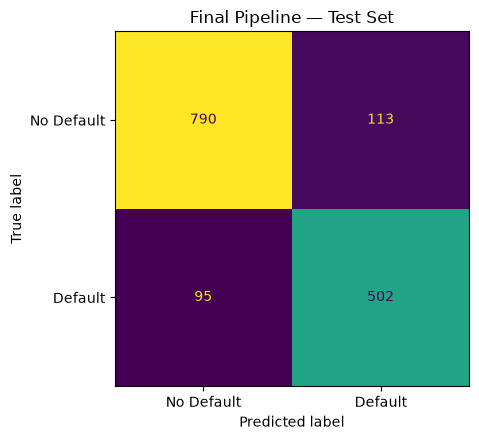

In [13]:
fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_test_pipe, display_labels=["No Default", "Default"], ax=ax, colorbar=False
)
ax.set_title("Final Pipeline — Test Set")
plt.tight_layout()
plt.show()

**Exact match**: 82.7% train recall / 84.1% test recall, identical to `selected_model` evaluated
on the manually-engineered, imputed, and encoded data. The pipeline, fit directly on the raw
training split with no `Amount_per_Month` column and missing values still present, reproduces the
selected model bit-for-bit, confirming the packaging step changed nothing about the model's
behaviour.

## <font color="brown"> Traditional Method vs. Pipeline: Side by Side</font>

| Aspect | Traditional (Manual) | Pipeline |
|---|---|---|
| Code structure | Several separate steps, each reassigning a dataframe by hand | One object; one `.fit()`, one `.predict()` |
| Repeating preprocessing on new data | Has to be redone by hand, in the exact same order, every time | Runs automatically, in order, whenever `.fit()`/`.predict()` is called |
| Leakage risk | Real, and easy to get wrong, imputing before splitting (as the first draft of Step 1 in this notebook actually did) silently lets test rows influence training-time fill values | Structurally harder to leak: a step only ever sees whatever is passed to `.fit()` |
| Deploying/reusing the model | Model and preprocessing logic live separately; easy for them to drift out of sync over time | Model and preprocessing are one saved/loaded object, they can't drift apart |
| Hyperparameter tuning | Tunes the model only, unless preprocessing choices are tuned separately by hand | `GridSearchCV` can tune preprocessing and model choices together, via `step__param` |
| Visibility while debugging | Every intermediate dataframe (imputed, encoded, ...) is sitting there to inspect | Intermediate outputs are hidden inside the pipeline unless a step is inspected directly |

That last row is a genuine trade-off, not just an advantage for pipelines. While building this
notebook, seeing `X_train_imputed` and `X_train`/`X_test` as separate, inspectable dataframes is
exactly what made it possible to notice (and fix) a leakage bug in an earlier draft, imputing
before splitting, a mistake that would have been easier to miss inside a pipeline's hidden
intermediate steps. Pipelines remove a category of mistakes at the cost of some of that
step-by-step visibility, prototype and debug with the traditional approach first, then package
into a pipeline once the logic is right.

## <font color="brown"> Business Insights and Recommendations</font>

- **Data leakage isn't hypothetical, an earlier draft of this notebook had it.** The first version
  of Step 1 imputed missing values (median/mode) on the *full* dataset before splitting, which lets
  the fill values used for training rows be quietly informed by test rows too. Fixing it meant
  splitting first, then computing the median/mode from `X_train_raw` only, and applying those exact
  values to both splits. The effect on this dataset was small (base tree test recall moved from
  81.9% to 81.7%), but the mechanism is real, and on a smaller dataset, or a feature more sensitive
  to its fill value, it could matter far more.

- **The pipeline never had this bug, structurally.** `final_pipeline.fit(X_train_raw, y_train)`
  only ever sees the training rows, by construction, there's no way to accidentally hand it test
  data the way a manual script can accidentally impute before splitting. That's a real, if
  understated, argument for pipelines: they don't just save code, they remove an entire category
  of mistakes from being possible in the first place.

- **Feature engineering slots into a pipeline exactly like imputation or encoding.**
  `Amount_per_Month` is a plain Python function wrapped in `FunctionTransformer`, no custom class
  needed, and it sits as the first step in `final_pipeline`, before the `ColumnTransformer`. Any
  stateless transformation (a ratio, a flag, a log transform) can be added the same way.

- **Packaging into a pipeline changed nothing about the result.** The final pipeline's recall
  (82.7% train / 84.1% test) exactly matches `selected_model`'s recall on the manually-engineered,
  train-only-imputed data. The pipeline is not a different model, it's the same selected model plus
  every preprocessing step it depends on, bundled into one object.

- **What the pipeline actually buys you is at prediction time.** `selected_model` only accepts
  input that has already been engineered, imputed, and encoded exactly right, whoever uses it
  later has to remember and correctly repeat all three steps, in order. `final_pipeline` accepts
  the same raw columns the dataset started with and does all three itself, there's nothing separate
  left to forget or get wrong.

- **The right order to learn this in**: understand data leakage first, then build and tune a model
  the normal way (as `Decision Trees` did, and as Steps 1-3 here repeat), understanding what the
  model needs, including any engineered features and missing data, along the way. Only once a
  specific model is selected does it make sense to package it into a pipeline, that packaging is a
  deployment/reuse convenience on top of a modeling decision already made, and a source of
  structural safety, not a substitute for making that decision.

- **Recommendation**: after selecting a final model through the usual build-tune-select workflow,
  wrap its exact feature engineering, imputation, encoding, and hyperparameters into a `Pipeline`
  before saving or deploying it, so the model and every step it depends on travel together as one
  reusable, leakage-resistant object.